# VAE + NN Regression
This notebook aims to perform a regression on the production of solar, wind and hydro renewable energy. To achieve this, we are going to use a VAE + NN configuration. The VAE is going to be in charge of reducing the dimensionality of the problem, while the NN will perform the regression itself.

## 0: Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
# from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

import optuna
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import json
import os

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit

from datetime import date

## 1: Import the data
We want to use as features the meteo forecast data that are outputted from notebook 1, while as label the outputs of notebook 2. Is important to **select zone and energy type** here.

In [2]:
# LUCA's IMPORTS
sel_zone = 'IT_NORD'
energies = ['solar','wind','hydro']
detrended_energies = ['detrended_solar','detrended_wind','detrended_hydro']
energy_colors = ['red','green','blue']
target_index = 2

df_features = pd.read_csv(f'1_output/{sel_zone}_meteo_forecast_data.csv')
df_labels = pd.read_csv(f'2_outputs/{sel_zone}_installation_detrended_actuals.csv')

# remove timezone information
df_labels['date_time'] = pd.to_datetime(df_labels['date_time'], utc= True).dt.tz_convert(None)
# sort by date
df_labels = df_labels.sort_values('date_time')
df_labels = df_labels.set_index('date_time')
# resample every 3h with no overlapping windows and keeping the first timestamp as index
start_time = df_labels.index[0]
groups = []
# Define which columns to sum and which to average
sum_columns = ['solar','wind','hydro','load','detrended_solar','detrended_wind','detrended_hydro']
mean_columns = ['ratio','solar_installed','wind_installed','hydro_installed']  # example

groups = []
start_time = df_labels.index[0]

while start_time + pd.Timedelta(hours=3) <= df_labels.index[-1] + pd.Timedelta(minutes=1):
    end_time = start_time + pd.Timedelta(hours=3)
    chunk = df_labels[start_time:end_time - pd.Timedelta(seconds=1)]

    if len(chunk) == 3 and all((chunk.index == [start_time + pd.Timedelta(hours=i) for i in range(3)])):
        summed = chunk[sum_columns].sum()
        averaged = chunk[mean_columns].mean()
        
        combined = pd.concat([summed, averaged])
        combined.name = start_time
        groups.append(combined)

    start_time += pd.Timedelta(hours=3)

# retrieve date time info
result_df = pd.DataFrame(groups).reset_index().rename(columns={'index': 'date_time'})

df_labels = result_df

# normalize time to range [0, 1]
min_time = df_labels['date_time'].min()
max_time = df_labels['date_time'].max()
df_labels['time'] = (df_labels['date_time'] - min_time) / (max_time - min_time)
df_labels['time'] = df_labels['time'].astype(float)  # convert timedelta to float

# keep only desired columns
df_labels = df_labels[['date_time', 'time', 'detrended_solar', 'detrended_wind', 'detrended_hydro']]
df_labels 

,date_time,time,detrended_solar,detrended_wind,detrended_hydro
0,2022-01-01 00:00:00,0.000000,0.000000,0.280479,0.318237
1,2022-01-01 03:00:00,0.000114,0.000000,0.396306,0.325232
2,2022-01-01 06:00:00,0.000228,0.036678,0.219479,0.396564
3,2022-01-01 09:00:00,0.000343,0.278125,0.384061,0.347202
4,2022-01-01 12:00:00,0.000457,0.189566,0.384035,0.341881
...,...,...,...,...,...
8730,2024-12-30 06:00:00,0.999543,0.095458,0.096029,0.550103
8731,2024-12-30 09:00:00,0.999657,0.519010,0.172852,0.344900
8732,2024-12-30 12:00:00,0.999772,0.330239,0.206462,0.339921
8733,2024-12-30 15:00:00,0.999886,0.006103,0.259278,0.669006


In [3]:
df_features

,Unnamed: 0,year_t-8,2t_t-8,solar_t-8,tp_t-8,ws_10m_t-8,ws_100m_t-8,hour_sin_t-8,hour_cos_t-8,day_sin_t-8,...,ws_100m_t-0,hour_sin_t-0,hour_cos_t-0,day_sin_t-0,day_cos_t-0,month_sin_t-0,month_cos_t-0,sin_dayofyear_t-0,cos_dayofyear_t-0,timestamp
0,0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.280164,...,-1.132097,-0.685682,1.408711,0.280448,1.400505,0.702453,1.109234,0.025586,1.291842,2022-01-01 21:00:00
1,1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.280164,...,-0.931334,0.249115,1.890286,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-02 00:00:00
2,2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.280164,...,-0.778698,1.183912,1.408711,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-02 03:00:00
3,3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.280164,...,-0.664870,1.571118,0.246088,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-02 06:00:00
4,4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.280164,...,-0.452988,1.183912,-0.916535,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-02 09:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.287572,...,-1.518295,0.249115,-1.398110,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-31 12:00:00
8316,8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.388240,-0.685682,-0.916535,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-31 15:00:00
8317,8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-31 18:00:00
8318,8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-31 18:00:00


### 1.1: Remove duplicated time information
Here we remove the duplicated time informations, such as day and month (we already have dayoftheyear that represents this same information)

In [4]:
# we use as temporal info the day of the year (1...365)
features = ['day_sin_t-0','day_cos_t-0',
           'day_sin_t-1','day_cos_t-1',
           'day_sin_t-2','day_cos_t-2',
           'day_sin_t-3','day_cos_t-3',
           'day_sin_t-4','day_cos_t-4',
           'day_sin_t-5','day_cos_t-5',
           'day_sin_t-6','day_cos_t-6',
           'day_sin_t-7','day_cos_t-7',
           'day_sin_t-8','day_cos_t-8',
           'month_sin_t-0','month_cos_t-0',
           'month_sin_t-1','month_cos_t-1',
           'month_sin_t-2','month_cos_t-2',
           'month_sin_t-3','month_cos_t-3',
           'month_sin_t-4','month_cos_t-4',
           'month_sin_t-5','month_cos_t-5',
           'month_sin_t-6','month_cos_t-6',
           'month_sin_t-7','month_cos_t-7',
           'month_sin_t-8','month_cos_t-8']

# in alternative one can use the following lines to keep day and month time info
'''
features = ['sin_dayofyear_t0','cos_dayofyear_t0',
            'sin_dayofyear_t1','cos_dayofyear_t1',
            'sin_dayofyear_t2','cos_dayofyear_t2',
            'sin_dayofyear_t3','cos_dayofyear_t3',
            'sin_dayofyear_t4','cos_dayofyear_t4',
            'sin_dayofyear_t5','cos_dayofyear_t5',
            'sin_dayofyear_t6','cos_dayofyear_t6',
            'sin_dayofyear_t7','cos_dayofyear_t7',
            'sin_dayofyear_t8','cos_dayofyear_t8','Unnamed: 0'] '''

df_features = df_features.drop(columns = features)

In [5]:
sel_cols = df_features.columns[1:]
df_features = df_features[sel_cols]
df_features
# methereological data every 3 hours, running over the course of a day  (10 features every 3 hour = 90 features)

,year_t-8,2t_t-8,solar_t-8,tp_t-8,ws_10m_t-8,ws_100m_t-8,hour_sin_t-8,hour_cos_t-8,sin_dayofyear_t-8,cos_dayofyear_t-8,...,2t_t-0,solar_t-0,tp_t-0,ws_10m_t-0,ws_100m_t-0,hour_sin_t-0,hour_cos_t-0,sin_dayofyear_t-0,cos_dayofyear_t-0,timestamp
0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.025562,1.291842,...,-1.279364,-0.785204,-0.539696,-0.982129,-1.132097,-0.685682,1.408711,0.025586,1.291842,2022-01-01 21:00:00
1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.025562,1.291842,...,-1.305169,-0.785204,-0.539696,-0.791966,-0.931334,0.249115,1.890286,0.050415,1.291222,2022-01-02 00:00:00
2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.025562,1.291842,...,-1.369257,-0.785204,-0.539696,-0.709343,-0.778698,1.183912,1.408711,0.050415,1.291222,2022-01-02 03:00:00
3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.025562,1.291842,...,-1.427837,-0.704916,-0.537695,-0.616626,-0.664870,1.571118,0.246088,0.050415,1.291222,2022-01-02 06:00:00
4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.025562,1.291842,...,-1.170501,0.196247,-0.537695,-0.573833,-0.452988,1.183912,-0.916535,0.050415,1.291222,2022-01-02 09:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.024044,1.291843,...,-0.518011,0.586399,-0.545575,-1.441098,-1.518295,0.249115,-1.398110,0.000749,1.292048,2024-12-31 12:00:00
8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-0.567924,-0.485478,-0.545575,-1.249467,-1.388240,-0.685682,-0.916535,0.000749,1.292048,2024-12-31 15:00:00
8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-31 18:00:00
8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-31 18:00:00


In [6]:
df_labels

,date_time,time,detrended_solar,detrended_wind,detrended_hydro
0,2022-01-01 00:00:00,0.000000,0.000000,0.280479,0.318237
1,2022-01-01 03:00:00,0.000114,0.000000,0.396306,0.325232
2,2022-01-01 06:00:00,0.000228,0.036678,0.219479,0.396564
3,2022-01-01 09:00:00,0.000343,0.278125,0.384061,0.347202
4,2022-01-01 12:00:00,0.000457,0.189566,0.384035,0.341881
...,...,...,...,...,...
8730,2024-12-30 06:00:00,0.999543,0.095458,0.096029,0.550103
8731,2024-12-30 09:00:00,0.999657,0.519010,0.172852,0.344900
8732,2024-12-30 12:00:00,0.999772,0.330239,0.206462,0.339921
8733,2024-12-30 15:00:00,0.999886,0.006103,0.259278,0.669006


### 1.2: Joining dataframes
Since some data was discarded in previous notebooks (presence of outliers), we need to ensure that features and labels are aligned over the time information. For this reason, we perform a inner join over the dataframes, ensuring consistency over features and labels.

In [7]:
# keeping only the ones in common
df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_features['date_time'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)
common = pd.merge(df_features, df_labels, on='date_time', how = 'inner')
df_labels = common[df_labels.columns]
df_features = common[df_features.columns]
print(np.shape(df_features),np.shape(df_labels))


(8288, 92) (8288, 5)


/tmp/ipykernel_1342545/2463686259.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)


### 1.3: Setting up Training and Test data
Since our aim is to make our model being able to predict future data from past data, we are going to split training and test set according to time index: the first 80% of our data points will represent our training set, the rest test set. Computation times are already long for our implementation, so we will avoid K-Folds such as time-rollings

In [8]:
X_array = df_features.drop(columns=['timestamp','date_time']).values # 24h windows
# pick the right label
Y_array = df_labels[detrended_energies[target_index]].values
print(f'Attempting the regression on {detrended_energies[target_index]}')

n_samples = len(X_array)
split_idx = int(n_samples * 0.8)


X_train = X_array[:split_idx]
X_test = X_array[split_idx:] # we do not randomly split into training and test set to avoid replicating data across both (it's a time-series with sliding windows)

Y_train = Y_array[:split_idx]
Y_test = Y_array[split_idx:]

# keep track of the original indices and timestamps
idx_train = df_features.index[:split_idx] # to retrieve date/time at test time (for predictions)
idx_test = df_features.index[split_idx:]

test_timestamps = df_features.loc[idx_test, 'timestamp'].reset_index(drop=True)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

# create a DataLoader for batching (training and test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Reshape the Y tensors (model consistency if we want multiple features)
Y_train_tensor = Y_train_tensor.view(-1, 1)
Y_test_tensor = Y_test_tensor.view(-1, 1)


Attempting the regression on detrended_hydro


### 1.4: Make directories to save screenshots and models

In [9]:
#### make directory for saving screenshots
base_dir = "4_plots"
zone_dir = os.path.join(base_dir, sel_zone)

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}'.")
except Exception as e:
    print(f"An error occurred: {e}")


#### make directory for saving screenshots
base_dir = "4_plots"
zone_dir = os.path.join(base_dir, sel_zone, energies[target_index])

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}'.")
except Exception as e:
    print(f"An error occurred: {e}")

# make directory for saving weights
base_dir = "4_weights"
zone_dir = os.path.join(base_dir, sel_zone, energies[target_index])

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}/{energies[target_index]}'.")
except Exception as e:
    print(f"An error occurred: {e}")

# make directory for saving studies
base_dir = "4_optuna"
zone_dir = os.path.join(base_dir, sel_zone, energies[target_index])

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}/{energies[target_index]}'.")
except Exception as e:
    print(f"An error occurred: {e}")

# make directory for saving BEST MODELS
base_dir = "4_best_models"
zone_dir = os.path.join(base_dir, sel_zone, energies[target_index])

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}/{energies[target_index]}'.")
except Exception as e:
    print(f"An error occurred: {e}")

Directory '4_plots/IT_NORD' is ready.
Directory '4_plots/IT_NORD/hydro' is ready.
Directory '4_weights/IT_NORD/hydro' is ready.
Directory '4_optuna/IT_NORD/hydro' is ready.
Directory '4_best_models/IT_NORD/hydro' is ready.


## 2: Setup the model and Training
### 2.1: Model definition

In [10]:

class VAE(nn.Module): # VAE inherits from nn.Module, base class for neural network modules in PyTorch.
    def __init__(self, input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, activation):
        super(VAE, self).__init__() # to call init method on the parent class of VAE (nn.Module) so that is has all the same functions

        # encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim1) # hidden_dim: hidden layer neurons of encoder NN
        self.fc2 = nn.Linear(hidden_dim1,hidden_dim2)
        self.fc_mu = nn.Linear(hidden_dim2, latent_dim) # latent_dim : output layer neurons of encoder NN
        self.fc_logvar = nn.Linear(hidden_dim2, latent_dim)

        # decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim3)
        self.fc4 = nn.Linear(hidden_dim3, input_dim)
        self.activation = activation

    def encode(self, x):
        #h1 = self.activation(self.batch1(self.fc1(x)))
        h1 = self.activation((self.fc1(x)))
        h2= self.activation(self.fc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)

    def reparameterize(self, mu, logvar): # reparametrization trick to allow backpropagation
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        #h = self.activation(self.batch2(self.fc2(z)))
        h3 = self.activation((self.fc3(z)))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z  # z are the latent representations of the input x


# VAE loss function (separate function, not class method)
def vae_loss(recon_x, x, mu, logvar):
        MSE = F.mse_loss(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return MSE + KLD, MSE, KLD



class Net(nn.Module):
    def __init__(self,Ni,N1,N2,No,activation): # Ni is the dimension of z, N1 the number of hidden neurons of the first layer, N2 the number of hidden neurons of the second layer
        super(Net,self).__init__()

        self.fc1 = nn.Linear(Ni,N1)
        self.batch1 =  nn.BatchNorm1d(N1)
        self.drop1 = nn.Dropout(p=0.1)
        
        self.fc2 = nn.Linear(N1,N2)
        self.batch2 =  nn.BatchNorm1d(N2)
        self.drop2 = nn.Dropout(p=0.1)

        # self.fc3 = nn.Linear(N2, N3)
        # self.batch3 = nn.BatchNorm1d(N3)
        # self.drop3 = nn.Dropout(p=0.1)
        
        self.out = nn.Linear(N2,No)
        self.act = activation


    def forward(self,z): # input from latent variables
            h1 = self.drop1(self.act(self.batch1(self.fc1(z))))
            h2 = self.drop2(self.act(self.batch2(self.fc2(h1))))
        
            #h1= self.act((self.fc1(z)))
            #h2 = self.act((self.fc2(h1)))
            #h3 = self.drop3(self.act(self.batch3(self.fc3(h2))))
            out = F.relu(self.out(h2))
            return (out)


    def regr_loss(self,y,output,lambda_tik):
        mse = F.mse_loss(output, y,reduction='sum')

        w_norm = 0.0
        for param in self.parameters():
            w_norm += torch.sum(torch.abs(param))

        return mse + lambda_tik*w_norm**2




# here we define the full network architecture for VAE+regression

class VAE_Regression(nn.Module):
    def __init__(self,input_dim, hidden_dim1,hidden_dim2,latent_dim,hidden_dim3,vae_activation,N1,N2,No,activation,lambda_tik):
        super(VAE_Regression,self).__init__()

        self.vae = VAE(input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, vae_activation)
        self.regression = Net(latent_dim,N1,N2,No,activation)
        
    def forward(self,x):
        reconstructed_x, mu, logvar, z = self.vae(x) # self.vae(x) is equivalent to calling self.vae.forward(x) thanks to nn.Module
        regr_output = self.regression(mu)
        return (regr_output,reconstructed_x, mu, logvar,z)

    def VAE_loss(self,reconstructed_x, x, mu, logvar): # here VAE_loss/regression_loss are methods of the VAE_Regression class to be accessed later
        return(vae_loss(reconstructed_x, x, mu, logvar))

    def regression_loss(self,y,regr_output,lambda_tik):
        return(self.regression.regr_loss(y,regr_output,lambda_tik))


### 2.2: Grid search on hyperparameters space
The aim of the following cells is to run a grid search on hyperparameters space. The only free parameter (here arbitrarily set up, according to qualitative loss trends) is $\beta$, which rescales VAE loss to be (as far as possible) comparable with regression loss. This way the machine should be able to weigh correctly the two contributes and train the VAE in the best way to perform the regression.

In [11]:
beeta = 1. / 2000
# here we perform a grid search to look for the best hyperparameters: we choose to use 4 folds. We fix as objective to minimize the average validation error over the folds
# To compute each loss estimation before udating the weights, we perform 100 evaluations of the predicted outputs and consider their average as prediction

def get_activation(name):
    return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()
    }[name]

def objective(trial):

    save_dir = "4_weights_VAE_Regression/Single_hydro"
    os.makedirs(save_dir, exist_ok=True)
   
    hidden_dim1 = trial.suggest_categorical("hidden_dim1", [64,128,256]) # previous range 64-256
    hidden_dim2 = trial.suggest_categorical("hidden_dim2", [64,128,256]) #  previous range 64-256
    latent_dim = trial.suggest_categorical("latent_dim", [12,14,16,18,20]) # previous range 6-20
    hidden_dim3 = trial.suggest_categorical("hidden_dim3",[128,256] )  # previous range 64-256

    N1 = trial.suggest_categorical("N1", [64,128,256]) # previous range 16-256
    N2 = trial.suggest_categorical("N2", [64,128,256])

    lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6,1e-4, log=True)
    lr = trial.suggest_float("lr",1e-5,5*1e-4, log=True)
    act_name = trial.suggest_categorical("activation", ["relu"]) # previous searches also with sigmoid and leaky relu 
    activation_fn = get_activation(act_name)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 300
    batch_size = 16
    beta = beeta
    num_folds = 2
    patience= 35
    tscv = TimeSeriesSplit(n_splits=num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)
    fold_last10_regr_losses = []
    fold_model_paths = []


    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)

        #vae_act = get_activation("relu")

        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            # hidden_dim1=vae_best_params["H_DIM"],
            # latent_dim=vae_best_params["Z_DIM"],
            # hidden_dim2=vae_best_params["H_DIM"],
            hidden_dim1=hidden_dim1,
            hidden_dim2=hidden_dim2,
            latent_dim=latent_dim,
            hidden_dim3=hidden_dim3,
            vae_activation= activation_fn,
            N1=N1,
            N2=N2,
            No=Y_train_fold.shape[1],
            activation=activation_fn,
            lambda_tik=lambda_tik
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.25,       # wait 20 epochs of no improvement after which shrink LR by half
            patience=20)      

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        val_regr_loss_per_epoch = []
        best_val_regr = float('inf')
        early_stop_counter = 0
        best_model_state = None

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1 - beta) * regr_loss + beta * vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - beta) * regr_loss + beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            val_regr_loss_per_epoch.append(val_regr_loss_epoch)

            epoch_train_losses[epoch] += train_loss_epoch / num_folds
            epoch_val_losses[epoch] += val_loss_epoch / num_folds
            epoch_val_vae_losses[epoch] += val_vae_loss_epoch / num_folds
            epoch_val_regr_losses[epoch] += val_regr_loss_epoch / num_folds

            print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_regr_loss_epoch < best_val_regr: # early stopping: stop if val regr loss does not imporve for 20 epoxhs
                best_val_regr = val_regr_loss_epoch
                early_stop_counter = 0
                best_model_state = model.state_dict()
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} for fold {fold+1}")
                break

        # save best model state for this fold
        fold_model_path = f"4_weights/{sel_zone}/{energies[target_index]}/model_trial_{trial.number}_fold_{fold}.pt"
        torch.save(best_model_state, fold_model_path)
        fold_model_paths.append(fold_model_path)

        # average last 10 epochs val regression loss for fold
        fold_avg_regr_last10 = np.mean(val_regr_loss_per_epoch[-10:])
        fold_last10_regr_losses.append(fold_avg_regr_last10)

    # save paths of all fold models in trial attributes
    trial.set_user_attr("fold_model_paths", fold_model_paths)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    # return average regression loss across folds (last 10 epochs)
    return np.mean(fold_last10_regr_losses)

This cell runs the above study. It can be skipped if the study was already ran and it's only needed to load it.

In [12]:
# get current day and month
day = date.today().day
month_name = date.today().strftime("%B")

study = optuna.create_study(study_name= f"{energies[target_index]}_study_{day}_{month_name}", direction="minimize",
    storage=f"sqlite:///{energies[target_index]}_optuna.db",
    load_if_exists=True,pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=125))

from tqdm import tqdm
n_trials = 30
study.optimize(objective, n_trials=n_trials,n_jobs=8,catch=(Exception,))

[I 2025-07-04 14:16:29,709] A new study created in RDB with name: hydro_study_4_July

KeyboardInterrupt



Fold 1 Epoch [1/300] - Total val loss: 8.6600, VAE: 680.4471, Regr: 8.3239
Fold 1 Epoch [1/300] - Total val loss: 15.7188, VAE: 672.7169, Regr: 15.3901
Fold 1 Epoch [1/300] - Total val loss: 29.3529, VAE: 671.4409, Regr: 29.0317
Fold 1 Epoch [1/300] - Total val loss: 97.8434, VAE: 677.9958, Regr: 97.5532
Fold 1 Epoch [1/300] - Total val loss: 51.5499, VAE: 668.3677, Regr: 51.2414
Fold 1 Epoch [1/300] - Total val loss: 6.4209, VAE: 687.1629, Regr: 6.0803
Fold 1 Epoch [1/300] - Total val loss: 49.4401, VAE: 691.3863, Regr: 49.1190
Fold 1 Epoch [1/300] - Total val loss: 26.7300, VAE: 674.6377, Regr: 26.4059
Fold 1 Epoch [2/300] - Total val loss: 13.4368, VAE: 685.6958, Regr: 13.1005
Fold 1 Epoch [2/300] - Total val loss: 8.7924, VAE: 673.6173, Regr: 8.4598
Fold 1 Epoch [2/300] - Total val loss: 6.3131, VAE: 680.6086, Regr: 5.9758
Fold 1 Epoch [2/300] - Total val loss: 85.6194, VAE: 672.3142, Regr: 85.3260
Fold 1 Epoch [2/300] - Total val loss: 33.6292, VAE: 691.8803, Regr: 33.2999
Fold 1 

[W 2025-07-04 14:17:28,246] Trial 6 failed with parameters: {'hidden_dim1': 64, 'hidden_dim2': 128, 'latent_dim': 20, 'hidden_dim3': 128, 'N1': 128, 'N2': 64, 'lambda_tik': 9.481876007864609e-06, 'lr': 1.8418418609072636e-05, 'activation': 'relu'} because of the following error: ZMQError('Socket operation on non-socket').
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.10/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_1322358/900080427.py", line 141, in objective
    print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")
  File "/home/ubuntu/.local/lib/python3.10/site-packages/ipykernel/iostream.py", line 694, in write
    self._schedule_flush()
  File "/home/ubuntu/.local/lib/python3.10/site-packages/ipykernel/iostream.py", line 590, in _schedule_flush
   

Fold 1 Epoch [3/300] - Total val loss: 6.2171, VAE: 676.4635, Regr: 5.8818Fold 1 Epoch [3/300] - Total val loss: 22.4242, VAE: 674.1912, Regr: 22.0981
Fold 1 Epoch [3/300] - Total val loss: 23.1012, VAE: 712.7756, Regr: 22.7562
Fold 1 Epoch [3/300] - Total val loss: 75.2487, VAE: 672.8797, Regr: 74.9497
Fold 1 Epoch [3/300] - Total val loss: 44.8679, VAE: 682.2197, Regr: 44.5491
Fold 1 Epoch [3/300] - Total val loss: 21.1454, VAE: 674.3533, Regr: 20.8186
Fold 1 Epoch [4/300] - Total val loss: 10.3862, VAE: 716.1683, Regr: 10.0332
Fold 1 Epoch [4/300] - Total val loss: 8.1485, VAE: 670.9910, Regr: 7.8169
Fold 1 Epoch [4/300] - Total val loss: 19.9066, VAE: 685.1252, Regr: 19.5738
Fold 1 Epoch [4/300] - Total val loss: 16.9934, VAE: 723.3402, Regr: 16.6401
Fold 1 Epoch [4/300] - Total val loss: 66.8576, VAE: 675.7130, Regr: 66.5530
Fold 1 Epoch [4/300] - Total val loss: 42.8425, VAE: 678.2934, Regr: 42.5246
Fold 1 Epoch [4/300] - Total val loss: 18.6502, VAE: 682.4455, Regr: 18.3182


## 3: Loading the best model and plot logic
Assuming the above code has run, a study is available for plotting. Here we want to check the results

In [12]:
# load the study (mind that the code takes the current day and month: change 'em freely!)
day = 3#date.today().day
month_name = "July"#date.today().strftime("%B")

study = optuna.load_study(
    study_name= f"{energies[target_index]}_study_{day}_{month_name}",
    storage=f"sqlite:///{energies[target_index]}_optuna.db"
)

best_trial= study.best_trial
best_params= best_trial.params

best_params

{'hidden_dim1': 256,
 'hidden_dim2': 128,
 'latent_dim': 20,
 'hidden_dim3': 128,
 'N1': 256,
 'N2': 256,
 'lambda_tik': 7.05214815933246e-05,
 'lr': 0.00018048913159790733,
 'activation': 'relu'}

### 3.1: Saving the best model

In [13]:

# get its best hyperparameters
best_activation = get_activation(best_params["activation"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fold_paths = best_trial.user_attrs["fold_model_paths"]

best_model = VAE_Regression(
            input_dim= X_train.shape[1],
            hidden_dim1=best_params['hidden_dim1'],
            hidden_dim2=best_params['hidden_dim2'],
            latent_dim=best_params['latent_dim'],
            hidden_dim3=best_params['hidden_dim3'],
            vae_activation= best_activation,
            N1=best_params['N1'],
            N2=best_params['N2'],
            No= Y_test_tensor.shape[1],
            activation= best_activation,
            lambda_tik=best_params['lambda_tik']
        ).to(device)

# load the weights of the best trial
best_model.load_state_dict(torch.load(fold_paths[0], map_location=device))


trial=1
trial += 1
# saves current hyperparamters and weights (which you just loaded) into a new file
with open(f"4_best_models/{sel_zone}/{energies[target_index]}/best_model.json", "w") as f:
    json.dump(best_params, f)

torch.save(best_model.state_dict(), f"best_model_{energies[target_index]}_{day}_{month_name}_trial_{trial}.pt")



### 3.2: Preliminary plots
Plots of this section are not definitive: what we want here is to get an idea of the losses' trends and how the model is performing with a general tuning

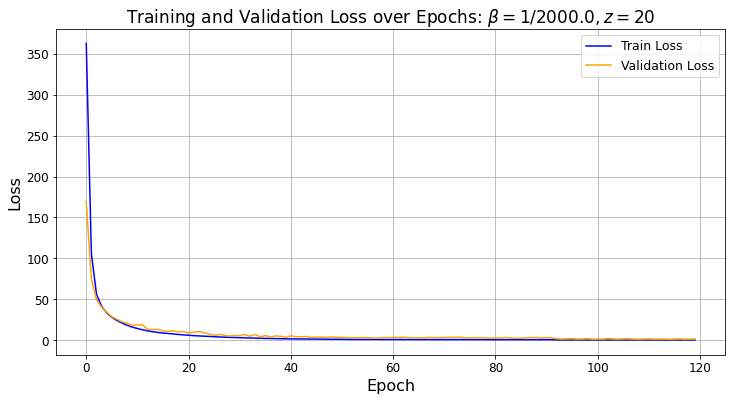

In [14]:
# plot training and validation losses over epochs
z = best_params['latent_dim']
#best_model.load_state_dict(torch.load("lcpb_files/best_model_overall.pt"))

train_loss_curve = np.array(best_trial.user_attrs["mean_train_loss_curve"])
val_loss_curve = np.array(best_trial.user_attrs["mean_val_loss_curve"])
val_vae_loss_curve = np.array(best_trial.user_attrs["mean_val_vae_loss_curve"])
val_regr_loss_curve = np.array(best_trial.user_attrs["mean_val_regr_loss_curve"])

# get only where the loss != 0 (early stopping eventuality)
epochs = np.arange(len(train_loss_curve[train_loss_curve!=0]))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve[train_loss_curve!=0], label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve[val_loss_curve!=0], label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(fr"Training and Validation Loss over Epochs: $\beta=1/{1./beeta},z={z}$")
plt.legend()
plt.grid(True)
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/3.2_train_val_loss.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

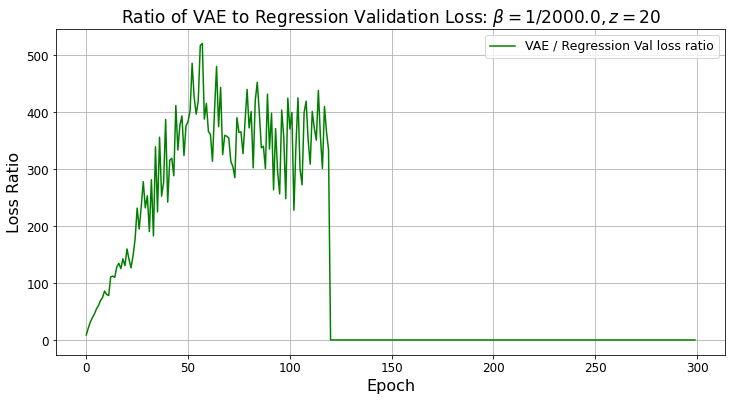

In [15]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero
epochs = np.arange(len(loss_ratio))

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio, label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(fr"Ratio of VAE to Regression Validation Loss: $\beta=1/{1./beeta},z={z}$")
plt.grid(True)
plt.legend()
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/3.2_val_loss_ratio.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

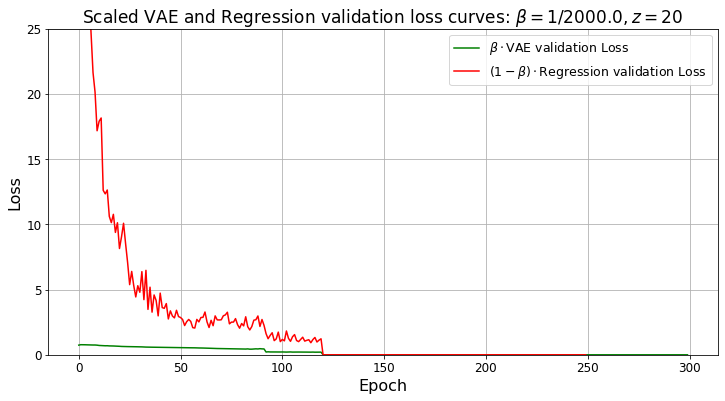

In [16]:
fig,ax= plt.subplots(figsize=(12,6))

ax.plot(epochs, beeta*val_vae_loss_curve, label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(fr"Scaled VAE and Regression validation loss curves: $\beta=1/{1./beeta},z={z}$")

ax.plot(epochs[:250], (1-beeta)*val_regr_loss_curve[:250], label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(0,25)
ax.grid(True)
ax.legend()
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/3.2_scaled_vae_regr_loss.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()


### 3.3: Model evaluation
The following cells perform a computation of the prediction of the label (this is still preliminary though) and plot the results

In [17]:
best_model.eval()

num_passes= 200

mean_preds = None

for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()
    recon_x = recon_x.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()


print(mean_test_predictions)

[[0.7727299 ]
 [0.74618894]
 [0.9672657 ]
 ...
 [0.35636932]
 [0.41270295]
 [0.43883538]]


In [18]:
print(np.shape(mean_test_predictions[:,0]))
print(np.shape(Y_test))

(1658,)
(1658,)


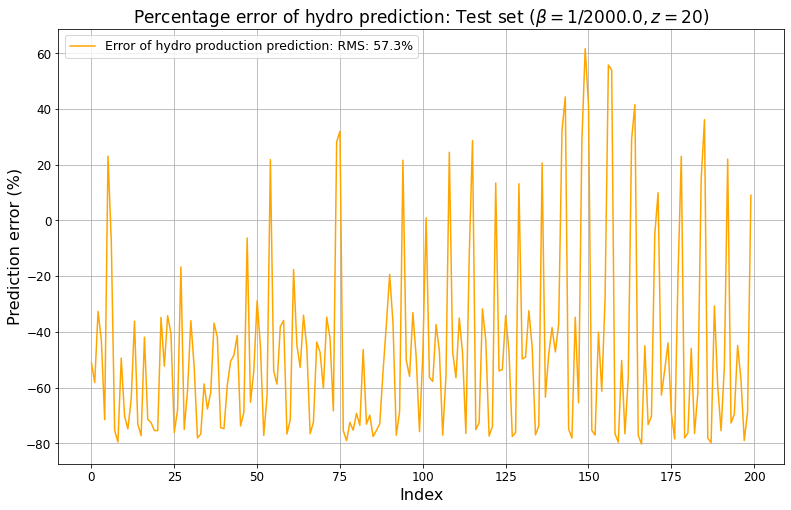

In [19]:
plt.figure(figsize=(13, 8))

# Mask zeros and very small values to avoid extreme divisions
epsilon = 1e-6
mask = np.where(np.abs(Y_test) > epsilon)[0]
masked_Y = Y_test[mask]
masked_pred = mean_test_predictions[mask,0]

# Limit points to plot
points_to_plot = min(200, len(masked_Y))

error_solar = (masked_pred[:points_to_plot] - masked_Y[:points_to_plot]) / masked_Y[:points_to_plot]
error_solar_percent = error_solar * 100

# Remove inf/nan values (just in case)
error_solar_percent = np.nan_to_num(error_solar_percent, nan=0.0, posinf=0.0, neginf=0.0)

plt.plot(np.arange(points_to_plot), error_solar_percent, color='orange',
         label=f'Error of {energies[target_index]} production prediction: RMS: {round(np.sqrt(np.mean(error_solar_percent**2)), 1)}%')

plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(fr"Percentage error of {energies[target_index]} prediction: Test set ($\beta=1/{1./beeta}, z={z}$)")
plt.grid(True)
plt.legend()

# Use lower dpi
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/3.3_label_prediction.png'
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()

## 4: Search for best $\beta$ parameter
The previous training was all about the structure. We did not run the search over $\beta$, which is the parameter that handles how losses interact, and so determines the effectiveness of our VAE in reducing the dimensionality aiming to a good regression performance. The following cells will try to handle it.

First of all, let's take the previous best parameters and save them. We are going to set these up for the training, this time looking for the best **$\beta$** parameter over a possible range

In [20]:
hd1 = best_params['hidden_dim1']
hd2 = best_params['hidden_dim2']
z = best_params['latent_dim']
hd3 = best_params['hidden_dim3']
n1 = best_params['N1']
n2 = best_params['N2']
ltk = best_params['lambda_tik']
learning_rate = best_params['lr']
act = best_params['activation']

# beta range and step
beta_min = 50
beta_max = 500
step = 50

### 4.1: Training definition

In [21]:
# fix previous best hyper parameters and find best beta

def objective(trial):

    def get_activation(name):
        return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()}[name]

    beta = trial.suggest_float("beta",beta_min,beta_max, step = step) # choose a reasonable range according to previous results
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 250
    batch_size = 16
    num_folds = 2
    early_stop_patience = 35
    tscv = TimeSeriesSplit(n_splits= num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    best_val_loss = float('inf')
    best_model_state = None

    fold_val_regr_curves = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]
        
        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)
        
        lambda_tik = ltk
        
        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            hidden_dim1=hd1,
            hidden_dim2=hd2,
            latent_dim=z,
            hidden_dim3=hd3,
            vae_activation=get_activation('relu'),
            N1=n1,
            N2=n2,
            No=Y_train_fold.shape[1],
            activation=get_activation('relu'),
            lambda_tik=ltk
        ).to(device)

        lr =  learning_rate
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience= 20)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        no_improve_counter = 0
        best_fold_loss = float('inf')
        fold_val_regr_curve = []

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1-1./beta) * regr_loss + 1./beta*vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - 1. / beta) * regr_loss + 1. / beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            epoch_train_losses[epoch] += (train_loss_epoch) / num_folds
            epoch_val_losses[epoch] += (val_loss_epoch) / num_folds
            epoch_val_vae_losses[epoch] += (val_vae_loss_epoch) / num_folds
            epoch_val_regr_losses[epoch] += (val_regr_loss_epoch) / num_folds

            fold_val_regr_curve.append(val_regr_loss_epoch)

            print(f"Epoch [{epoch + 1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_loss_epoch < best_fold_loss: # early stopping
                best_fold_loss = val_loss_epoch
                no_improve_counter = 0
            else:
                no_improve_counter += 1
                if no_improve_counter >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch + 1} in fold {fold + 1}")
                    break

            if val_loss_epoch < best_val_loss:
                best_val_loss = val_loss_epoch
                best_model_state = model.state_dict()

        fold_val_regr_curves.append(fold_val_regr_curve)

    fold_model_path = f"4_weights/{sel_zone}/{energies[target_index]}/beta_trial_{trial.number}_fold_{fold}.pt"
    torch.save(best_model_state, fold_model_path)
    trial.set_user_attr("model_path", fold_model_path)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    trial.set_user_attr("final_vae_loss", epoch_val_vae_losses[-1])
    trial.set_user_attr("final_regr_loss", epoch_val_regr_losses[-1])

    mean_last10_regr_losses = []
    for curve in fold_val_regr_curves:
        if len(curve) >= 10:
            mean_last10_regr_losses.append(np.mean(curve[-10:]))
        else:
            mean_last10_regr_losses.append(np.mean(curve))

    return float(np.mean(mean_last10_regr_losses))


The following cell runs the training (if it was not ran before). If there is already a study in memory, this cell can be skipped

In [29]:
from tqdm import tqdm
n_trials = 10

# get current day and month
day = date.today().day
month_name = date.today().strftime("%B")


max_jobs = min(n_trials, os.cpu_count() or 4)  # for SQLite, avoid too many writers

study_beta = optuna.create_study( study_name= f"{energies[target_index]}_study_beta_{day}_{month_name}", direction="minimize",
    storage=f"sqlite:///{energies[target_index]}_optuna.db",
    load_if_exists=True,pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=125))


study_beta.optimize(objective, n_trials=n_trials,n_jobs=max_jobs,catch=(Exception,))

[I 2025-07-04 14:32:58,592] Using an existing study with name 'hydro_study_beta_4_July' instead of creating a new one.


Epoch [1/250] - Total val loss: 125.9211, VAE: 686.2890, Regr: 123.6706
Epoch [1/250] - Total val loss: 123.3792, VAE: 689.5066, Regr: 122.2447
Epoch [1/250] - Total val loss: 123.0017, VAE: 682.7508, Regr: 121.3979
Epoch [1/250] - Total val loss: 125.3808, VAE: 687.2315, Regr: 121.6100
Epoch [1/250] - Total val loss: 134.3104, VAE: 681.5804, Regr: 123.1417
Epoch [1/250] - Total val loss: 124.8841, VAE: 683.5359, Regr: 123.7646
Epoch [1/250] - Total val loss: 124.1499, VAE: 677.5416, Regr: 122.9175
Epoch [1/250] - Total val loss: 123.9235, VAE: 686.0329, Regr: 122.5147
Epoch [2/250] - Total val loss: 54.2762, VAE: 722.5902, Regr: 49.7909
Epoch [2/250] - Total val loss: 52.6082, VAE: 719.2835, Regr: 49.9308
Epoch [2/250] - Total val loss: 49.5896, VAE: 721.4814, Regr: 47.6644
Epoch [2/250] - Total val loss: 62.5010, VAE: 716.8867, Regr: 49.1462
Epoch [2/250] - Total val loss: 51.3138, VAE: 724.6899, Regr: 49.9643
Epoch [2/250] - Total val loss: 51.3825, VAE: 723.1046, Regr: 49.6990
Epoc

[I 2025-07-04 15:34:47,474] Trial 23 finished with value: 7.802926447001294 and parameters: {'beta': 450.0}. Best is trial 3 with value: 5.297345269273082.


Epoch [79/250] - Total val loss: 8.6218, VAE: 577.1945, Regr: 7.3554
Early stopping at epoch 79 in fold 2
Epoch [63/250] - Total val loss: 4.5995, VAE: 511.7568, Regr: 2.5627
Epoch [49/250] - Total val loss: 5.1932, VAE: 582.4629, Regr: 4.0363
Epoch [52/250] - Total val loss: 5.3535, VAE: 567.3383, Regr: 3.9450
Epoch [75/250] - Total val loss: 6.1733, VAE: 546.4202, Regr: 2.5475
Epoch [31/250] - Total val loss: 9.1585, VAE: 639.5929, Regr: 7.3521
Epoch [1/250] - Total val loss: 131.9941, VAE: 686.2311, Regr: 120.6832
Epoch [80/250] - Total val loss: 15.4040, VAE: 620.7723, Regr: 3.0496
Epoch [57/250] - Total val loss: 4.1666, VAE: 555.1178, Regr: 3.0625
Epoch [64/250] - Total val loss: 4.8335, VAE: 530.8693, Regr: 2.7209
Epoch [50/250] - Total val loss: 5.0855, VAE: 566.0990, Regr: 3.9612
Epoch [2/250] - Total val loss: 60.6437, VAE: 722.7214, Regr: 47.1319
Epoch [53/250] - Total val loss: 5.8498, VAE: 559.7221, Regr: 4.4617
Epoch [76/250] - Total val loss: 5.9170, VAE: 508.0531, Regr:

[I 2025-07-04 15:44:56,217] Trial 20 finished with value: 2.7094189416215144 and parameters: {'beta': 500.0}. Best is trial 20 with value: 2.7094189416215144.


...

Epoch [156/250] - Total val loss: 1.3926, VAE: 226.5784, Regr: 0.9414
Early stopping at epoch 156 in fold 2
Epoch [22/250] - Total val loss: 15.7309, VAE: 681.2799, Regr: 9.0081
Epoch [50/250] - Total val loss: 13.6299, VAE: 535.4914, Regr: 2.9796
Epoch [23/250] - Total val loss: 15.3492, VAE: 674.4406, Regr: 8.6917
Epoch [51/250] - Total val loss: 14.6371, VAE: 555.4737, Regr: 3.5996
Epoch [24/250] - Total val loss: 14.3764, VAE: 650.8500, Regr: 7.9474
Epoch [52/250] - Total val loss: 14.6784, VAE: 537.8981, Regr: 4.0004
Epoch [25/250] - Total val loss: 14.0102, VAE: 649.3679, Regr: 7.5924
Epoch [53/250] - Total val loss: 14.2717, VAE: 539.3991, Regr: 3.5549
Epoch [26/250] - Total val loss: 13.5115, VAE: 628.7731, Regr: 7.2968
Epoch [54/250] - Total val loss: 13.7123, VAE: 551.9160, Regr: 2.7285
Epoch [27/250] - Total val loss: 12.5549, VAE: 627.5576, Regr: 6.3428
Epoch [55/250] - Total val loss: 13.6658, VAE: 555.0927, Regr: 2.6162
Epoch [28/250] - Total val loss: 12.2188, VAE: 624.9

[I 2025-07-04 16:10:05,375] Trial 25 finished with value: 2.91853467083985 and parameters: {'beta': 50.0}. Best is trial 24 with value: 2.4447538518916363.


Epoch [126/250] - Total val loss: 6.3690, VAE: 263.9922, Regr: 1.1114
Early stopping at epoch 126 in fold 2
Epoch [97/250] - Total val loss: 7.9238, VAE: 563.3055, Regr: 2.3139
Epoch [98/250] - Total val loss: 8.3764, VAE: 593.5477, Regr: 2.4656
Epoch [99/250] - Total val loss: 7.6990, VAE: 569.2530, Regr: 2.0267
Epoch [100/250] - Total val loss: 7.8141, VAE: 549.1706, Regr: 2.3458
Epoch [101/250] - Total val loss: 3.0755, VAE: 235.9253, Regr: 0.7235
Epoch [102/250] - Total val loss: 3.2251, VAE: 237.9501, Regr: 0.8541
Epoch [103/250] - Total val loss: 3.2225, VAE: 243.1520, Regr: 0.7990
Epoch [104/250] - Total val loss: 3.1381, VAE: 239.3504, Regr: 0.7522
Epoch [105/250] - Total val loss: 3.1674, VAE: 233.5391, Regr: 0.8404
Epoch [106/250] - Total val loss: 3.1966, VAE: 247.0689, Regr: 0.7332
Epoch [107/250] - Total val loss: 2.9741, VAE: 225.0132, Regr: 0.7313
Epoch [108/250] - Total val loss: 3.1128, VAE: 240.6280, Regr: 0.7137
Epoch [109/250] - Total val loss: 3.0626, VAE: 233.4725

[I 2025-07-04 16:16:21,071] Trial 26 finished with value: 2.452335850101152 and parameters: {'beta': 100.0}. Best is trial 24 with value: 2.4447538518916363.


Epoch [235/250] - Total val loss: 3.2394, VAE: 234.1076, Regr: 0.9074
Early stopping at epoch 235 in fold 2


### 4.2: Retrieving the best model and final results

In [30]:
day = date.today().day
month_name = date.today().strftime("%B")

study_beta = optuna.load_study(
    study_name= f"{energies[target_index]}_study_beta_{day}_{month_name}",
    storage=f"sqlite:///{energies[target_index]}_optuna.db"
)

best_trial = study_beta.best_trial
best_params = best_trial.params
best_params

{'beta': 500.0}

In [31]:
# final training for the best hyper-parameters found

import os
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


best_trial= study_beta.best_trial
best_params= best_trial.params
beta = 1./best_params['beta']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lambda_tik= ltk
best_model = VAE_Regression(
     input_dim=X_train_tensor.shape[1],
     hidden_dim1=hd1,
     hidden_dim2=hd2,
     latent_dim=z,
     hidden_dim3=hd3,
     vae_activation=get_activation('relu'),
     N1=n1,
     N2=n2,
     No=Y_train_tensor.shape[1],
     activation=get_activation('relu'),
     lambda_tik=lambda_tik).to(device)

# REMOVE NAN
# Get mask for rows that are valid (no NaNs in any Y_test_tensor column)
valid_mask = ~torch.isnan(Y_test_tensor).any(dim=1)

# Apply mask to both X and Y tensors
X_test_tensor = X_test_tensor[valid_mask]
Y_test_tensor = Y_test_tensor[valid_mask]


train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=16, shuffle=True, drop_last = True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  Y_test_tensor),  batch_size=16, shuffle=False, drop_last = False)

num_epochs = 250
#beta       = 1/550.0 # best previously found
patience   = 35

train_curve     = []
test_curve      = []
test_vae_curve  = []
test_regr_curve = []

optimizer = torch.optim.Adam(best_model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=20)

best_test = float("inf")
no_imp    = 0
best_state= None

for ep in range(num_epochs):
    best_model.train()
    train_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, recon, mu, logvar, _ = best_model(xb)
        vl = best_model.VAE_loss(recon, xb, mu, logvar)[0]
        rl = best_model.regression_loss(yb, pred, lambda_tik)
        loss = (1-beta)*rl + beta*vl
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        optimizer.step()
        train_sum += loss.item()
    train_curve.append(train_sum/len(train_loader))

    best_model.eval()
    t_sum = v_sum = r_sum = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred, recon, mu, logvar, _ = best_model(xb)
            vl = best_model.VAE_loss(recon, xb, mu, logvar)[0].item()
            rl = best_model.regression_loss(yb, pred,lambda_tik).item()
            t_sum += (1-beta)*rl + beta*vl
            v_sum += vl
            r_sum += rl
    te = t_sum/len(test_loader)
    tv = v_sum/len(test_loader)
    tr = r_sum/len(test_loader)
    test_curve.append(te)
    test_vae_curve.append(tv)
    test_regr_curve.append(tr)

    print(f"Epoch {ep+1}/{num_epochs} - Val Total: {te:.4f}, VAE: {tv:.4f}, Regr: {tr:.4f}")

    
    if tr < best_test:
        best_test = tr
        best_state= best_model.state_dict()
        no_imp    = 0
    else:
        no_imp += 1
        if no_imp >= patience:
            break

best_model.load_state_dict(best_state)
os.makedirs(f"best_Regr_models/Single_{energies[target_index]}", exist_ok=True)
torch.save(best_state, f"best_Regr_models/Single_{energies[target_index]}/best_model_{energies[target_index]}_{day}{month_name}_{sel_zone}_FINAL.pt")

train_loss_curve    = np.array(train_curve)
val_loss_curve      = np.array(test_curve)
val_vae_loss_curve  = np.array(test_vae_curve)
val_regr_loss_curve = np.array(test_regr_curve)


Epoch 1/250 - Val Total: 76.6383, VAE: 1705.7420, Regr: 73.3736
Epoch 2/250 - Val Total: 43.2174, VAE: 1650.7844, Regr: 39.9958
Epoch 3/250 - Val Total: 30.0792, VAE: 1600.5399, Regr: 26.9320
Epoch 4/250 - Val Total: 24.0186, VAE: 1482.7816, Regr: 21.0952
Epoch 5/250 - Val Total: 18.9140, VAE: 1423.7098, Regr: 16.0988
Epoch 6/250 - Val Total: 15.7174, VAE: 1313.0679, Regr: 13.1175
Epoch 7/250 - Val Total: 16.7274, VAE: 1196.2185, Regr: 14.3637
Epoch 8/250 - Val Total: 12.4581, VAE: 1103.6790, Regr: 10.2713
Epoch 9/250 - Val Total: 11.3593, VAE: 935.2642, Regr: 9.5078
Epoch 10/250 - Val Total: 10.8780, VAE: 760.7535, Regr: 9.3753
Epoch 11/250 - Val Total: 9.4874, VAE: 705.7038, Regr: 8.0922
Epoch 12/250 - Val Total: 8.9486, VAE: 684.0114, Regr: 7.5958
Epoch 13/250 - Val Total: 8.5240, VAE: 651.4517, Regr: 7.2356
Epoch 14/250 - Val Total: 6.7842, VAE: 635.3397, Regr: 5.5245
Epoch 15/250 - Val Total: 5.2266, VAE: 615.3624, Regr: 4.0038
Epoch 16/250 - Val Total: 6.7422, VAE: 591.8755, Regr

# 5: Visualization of reconstructed features and final results
### 5.1: final results and losses

In [32]:
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_pred_vs_test_final.png'

best_model.eval()
num_passes = 100

mean_preds = None
for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()

mean_test_predictions

array([[1.6963155],
       [1.7218473],
       [1.3907833],
       ...,
       [1.0612445],
       [0.9979086],
       [0.9951857]], dtype=float32)

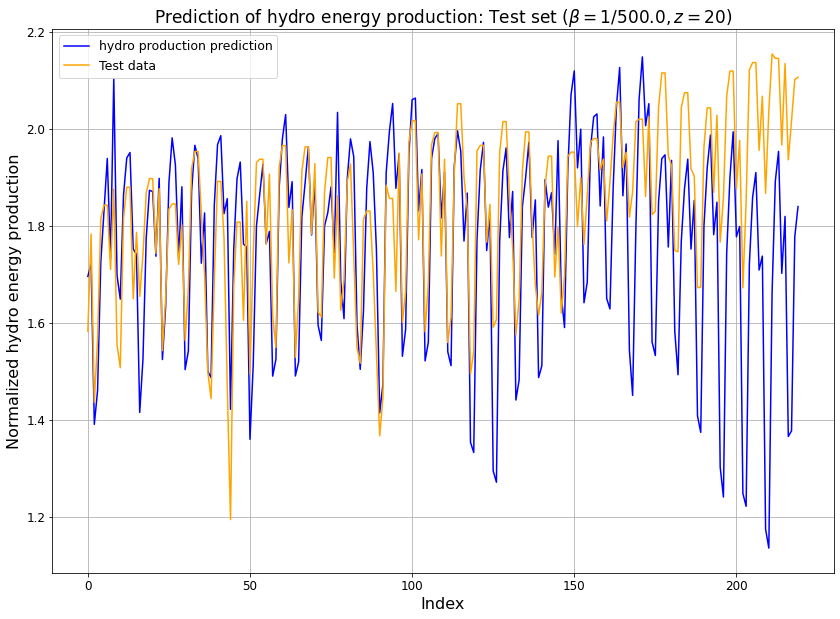

In [33]:
plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
    })

points_to_plot = 220
energy_colors = ['red','green','blue']

plt.figure(figsize = (14,10))
plt.plot(np.arange(points_to_plot),mean_test_predictions[:points_to_plot], color = energy_colors[target_index], label = f'{energies[target_index]} production prediction')
plt.plot(np.arange(points_to_plot),Y_test[:points_to_plot],color ='orange', label = 'Test data')
plt.xlabel("Index")
plt.ylabel(f"Normalized {energies[target_index]} energy production")
plt.title(fr"Prediction of {energies[target_index]} energy production: Test set ($\beta=1/{best_params['beta']}, z={z}$)")
plt.grid(True)
plt.legend()
#plt.ylim(1,max(Y_test[:points_to_plot])+0.2)
plt.savefig(filepath, dpi = 300, bbox_inches = 'tight')
plt.show()

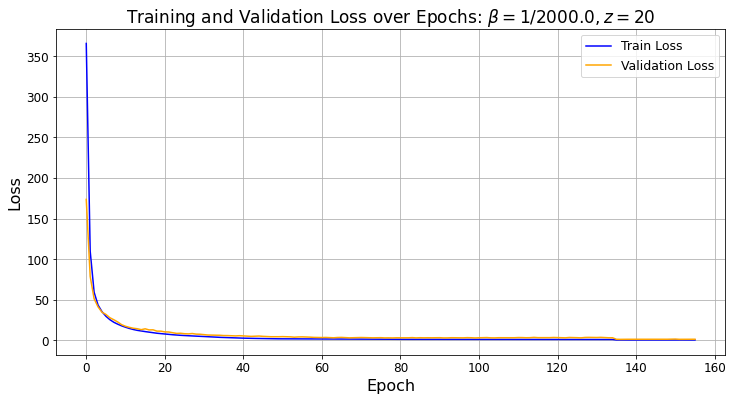

In [34]:
# plot training and validation losses over epochs
#best_model.load_state_dict(torch.load("lcpb_files/best_model_overall.pt"))

train_loss_curve = np.array(best_trial.user_attrs["mean_train_loss_curve"])
val_loss_curve = np.array(best_trial.user_attrs["mean_val_loss_curve"])
val_vae_loss_curve = np.array(best_trial.user_attrs["mean_val_vae_loss_curve"])
val_regr_loss_curve = np.array(best_trial.user_attrs["mean_val_regr_loss_curve"])

# get only where the loss != 0 (early stopping eventuality)
epochs = np.arange(len(train_loss_curve[train_loss_curve!=0]))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve[train_loss_curve!=0], label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve[val_loss_curve!=0], label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(fr"Training and Validation Loss over Epochs: $\beta=1/{1./beeta},z={z}$")
plt.legend()
plt.grid(True)
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_train_val_loss.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

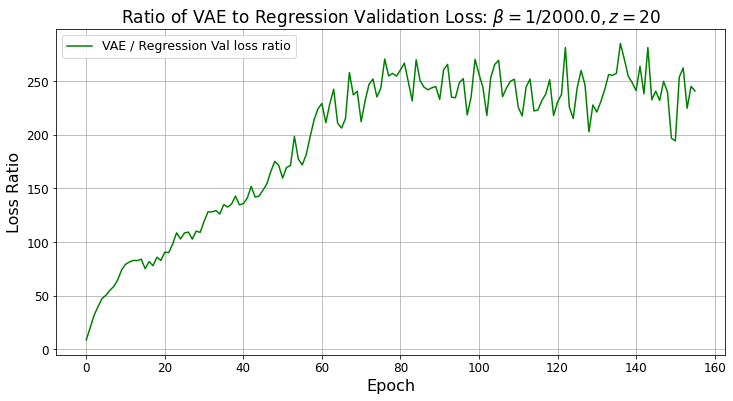

In [35]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero
loss_ratio = loss_ratio[loss_ratio > 0]
epochs = np.arange(len(loss_ratio))

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio, label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(fr"Ratio of VAE to Regression Validation Loss: $\beta=1/{1./beeta},z={z}$")
plt.grid(True)
plt.legend()
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_val_loss_ratio.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

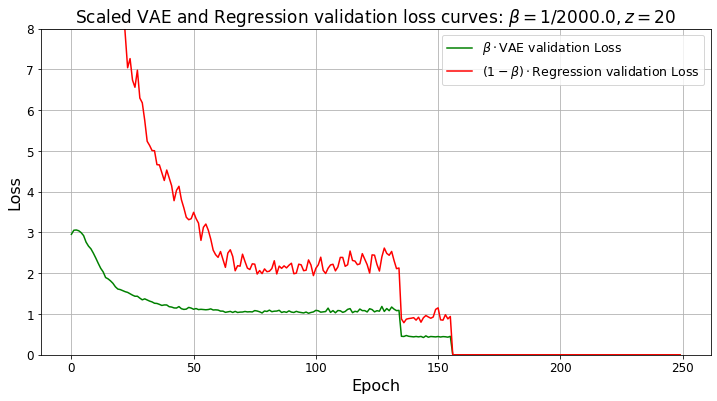

In [36]:
fig,ax= plt.subplots(figsize=(12,6))
epochs = np.arange(250)
ax.plot(epochs, beta*val_vae_loss_curve, label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(fr"Scaled VAE and Regression validation loss curves: $\beta=1/{1./beeta},z={z}$")

ax.plot(epochs, (1-beta)*val_regr_loss_curve[:250], label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(0,8)
ax.grid(True)
ax.legend()
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_scaled_vae_regr_loss.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()


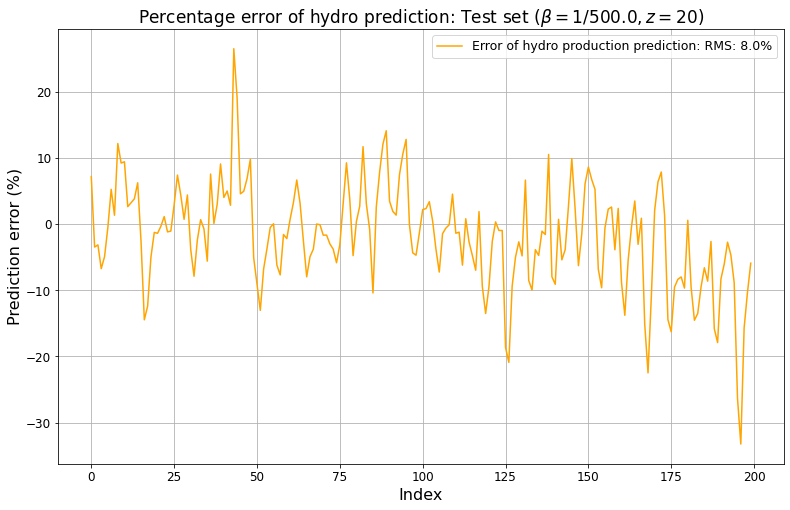

In [39]:
plt.figure(figsize=(13, 8))

# Mask zeros and very small values to avoid extreme divisions
epsilon = 1e-6
mask = np.where(np.abs(Y_test) > epsilon)[0]
masked_Y = Y_test[mask]
masked_pred = mean_test_predictions[mask,0]

# Limit points to plot
points_to_plot = min(200, len(masked_Y))

error_solar = (masked_pred[:points_to_plot] - masked_Y[:points_to_plot]) / masked_Y[:points_to_plot]
error_solar_percent = error_solar * 100

# Remove inf/nan values (just in case)
error_solar_percent = np.nan_to_num(error_solar_percent, nan=0.0, posinf=0.0, neginf=0.0)

plt.plot(np.arange(points_to_plot), error_solar_percent, color='orange',
         label=f'Error of {energies[target_index]} production prediction: RMS: {round(np.sqrt(np.mean(error_solar_percent**2)), 1)}%')

plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(fr"Percentage error of {energies[target_index]} prediction: Test set ($\beta=1/{1./beta}, z={z}$)")
plt.grid(True)
plt.legend()

# Use lower dpi
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_error_prediction.png'
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()

### 5.2: reconstructing features

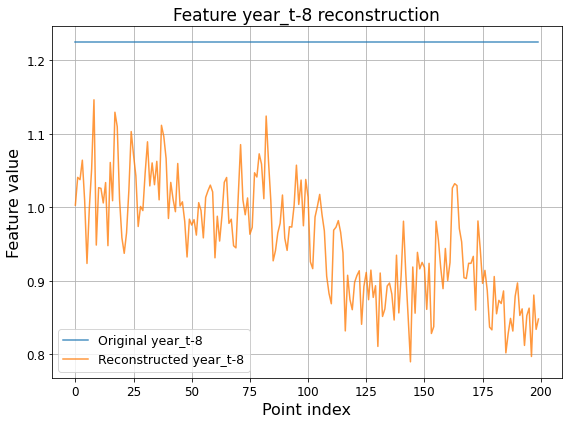

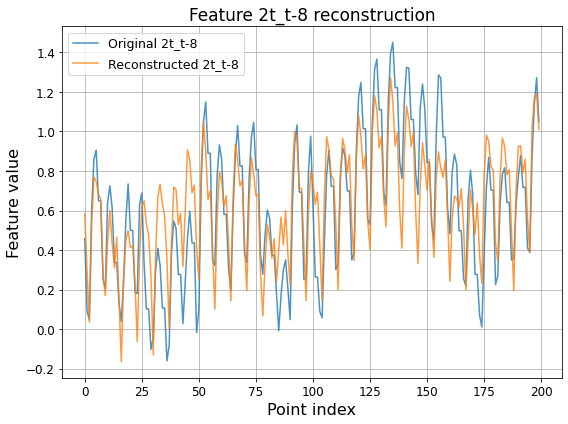

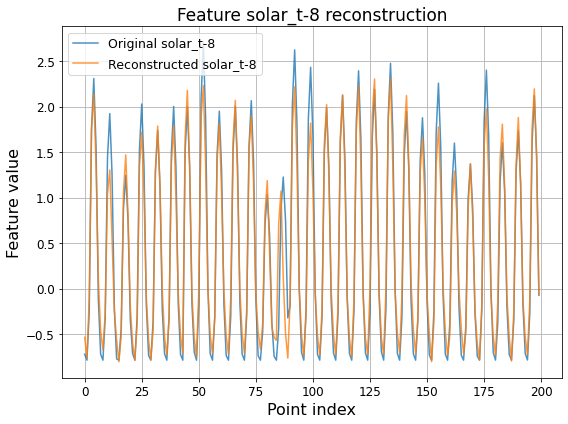

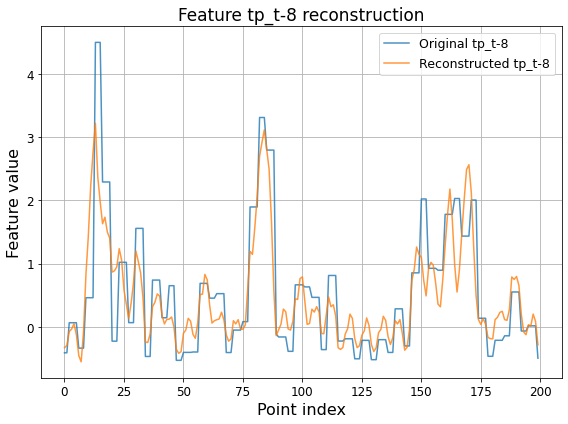

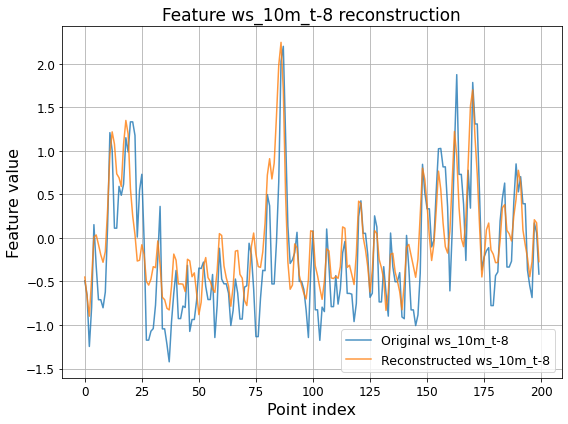

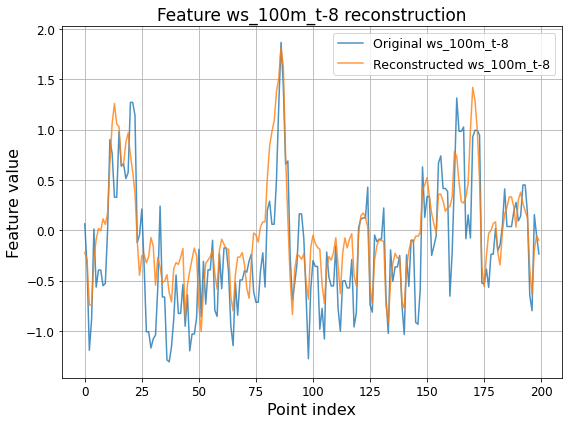

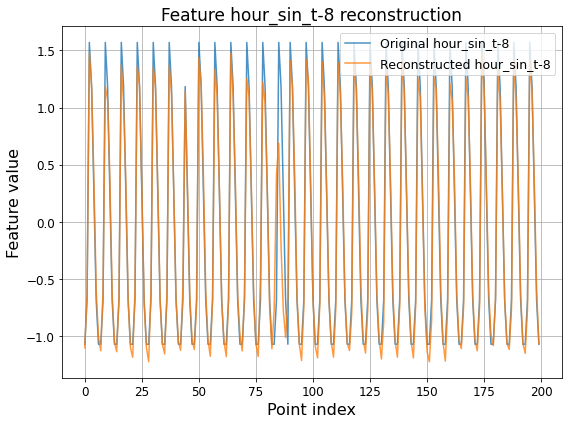

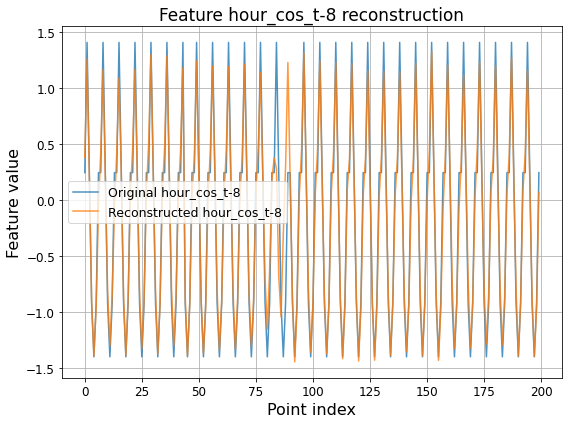

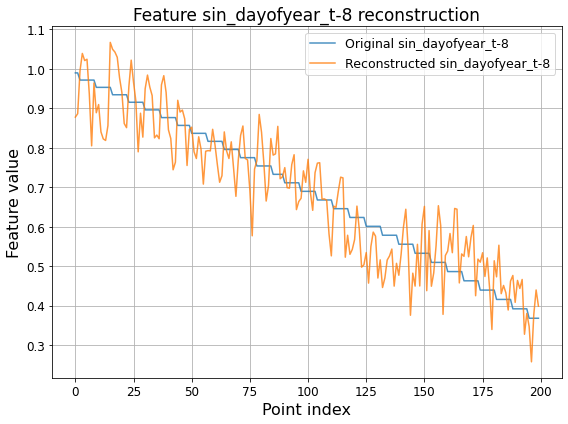

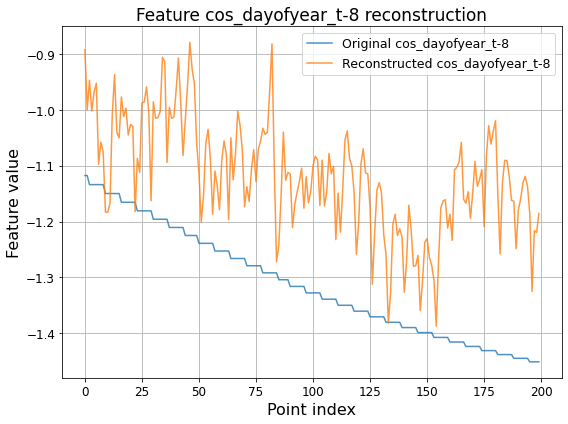

In [38]:
original_all = X_test
reconstructed_all = mean_recon_x_test

feature_names = df_features.drop(columns = ['timestamp']).columns.tolist()
features_to_plot = np.arange(0,10,1)

points_to_plot = 200
dummy_x = np.arange(points_to_plot)

for feature_idx in features_to_plot:
    plt.figure(figsize = (8,6))
    plt.plot(dummy_x,
            original_all[:points_to_plot,feature_idx],
            alpha = 0.8,
            label = f'Original {feature_names[feature_idx]}')
    plt.plot(dummy_x,
            reconstructed_all[:points_to_plot,feature_idx],
            alpha = 0.8,
            label = f'Reconstructed {feature_names[feature_idx]}')
    plt.xlabel('Point index')
    plt.ylabel('Feature value')
    plt.title(f'Feature {feature_names[feature_idx]} reconstruction')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename = f'4_plots/{sel_zone}/{energies[target_index]}/5.2_VAE_reconstruction_feature_{feature_idx}.png'
    plt.savefig(filename, dpi = 300, bbox_inches = 'tight')
    plt.show()